In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


2026-02-17 21:37:57.945712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-17 21:37:58.041793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771339078.080180    7446 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771339078.091941    7446 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771339078.166143    7446 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
DWT_TRAIN_DIR = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/dwt/train452"
DWT_TEST_DIR  = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/dwt/test452"


In [3]:
def build_cnn_tow_ids():

    model = models.Sequential([
        layers.Input(shape=(226, 226, 3)),

        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [4]:
# total = 438070 + 353478

# class_weight = {
#     0: total / (2 * 438070),  # Normal
#     1: total / (2 * 353478)   # Attack
# }

# class_weight


In [5]:
import os

DWT_TRAIN_DIR = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/dwt/train452"

train_parts = sorted([
    f for f in os.listdir(DWT_TRAIN_DIR)
    if f.endswith(".npz")
])

print("Jumlah train part:", len(train_parts))
print("Contoh part:", train_parts[:3])


Jumlah train part: 85
Contoh part: ['train_dwt_part_001.npz', 'train_dwt_part_002.npz', 'train_dwt_part_003.npz']


In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import os, gc, random
import numpy as np

EPOCHS = 16        # GLOBAL epoch (dikunci)
BATCH_SIZE = 2

model = build_cnn_tow_ids()

# pastikan train_parts sudah berisi daftar file .npz
for epoch in range(EPOCHS):
    print(f"\nGlobal Epoch {epoch+1}/{EPOCHS}")
    random.shuffle(train_parts)

    for i, part in enumerate(train_parts, 1):
        print(f"  Training part {i}/{len(train_parts)}: {part}")

        data = np.load(os.path.join(DWT_TRAIN_DIR, part))
        X = data["X"]
        y = data["y"]

        idx = np.random.permutation(len(X))
        X = X[idx]
        y = y[idx]

        history = model.fit(
            X, y,
            epochs=1,
            batch_size=BATCH_SIZE,
            # class_weight=class_weight,
            shuffle=False,
            verbose=0
        )

        print(
            f"    loss={history.history['loss'][0]:.4f}, "
            f"acc={history.history['accuracy'][0]:.4f}"
        )

        del X, y, data
        gc.collect()



I0000 00:00:1771339080.089530    7446 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



Global Epoch 1/16
  Training part 1/85: train_dwt_part_043.npz


I0000 00:00:1771339081.670881    7623 service.cc:152] XLA service 0x74723800bfe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771339081.670904    7623 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-02-17 21:38:01.706167: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771339081.915282    7623 cuda_dnn.cc:529] Loaded cuDNN version 91701
I0000 00:00:1771339083.659787    7623 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    loss=0.0116, acc=0.9840
  Training part 2/85: train_dwt_part_014.npz
    loss=0.0000, acc=1.0000
  Training part 3/85: train_dwt_part_082.npz
    loss=0.0000, acc=1.0000
  Training part 4/85: train_dwt_part_068.npz
    loss=8.5574, acc=0.9520
  Training part 5/85: train_dwt_part_054.npz
    loss=0.0000, acc=1.0000
  Training part 6/85: train_dwt_part_049.npz
    loss=2.8341, acc=0.9360
  Training part 7/85: train_dwt_part_032.npz
    loss=0.3628, acc=0.8240
  Training part 8/85: train_dwt_part_006.npz
    loss=1.8316, acc=0.4762
  Training part 9/85: train_dwt_part_037.npz
    loss=0.6356, acc=1.0000
  Training part 10/85: train_dwt_part_073.npz
    loss=0.7653, acc=0.0000
  Training part 11/85: train_dwt_part_042.npz
    loss=0.7203, acc=0.0000
  Training part 12/85: train_dwt_part_075.npz
    loss=0.6792, acc=0.8560
  Training part 13/85: train_dwt_part_013.npz
    loss=0.6424, acc=1.0000
  Training part 14/85: train_dwt_part_009.npz
    loss=0.7550, acc=0.0000
  Training part 15

In [8]:
import os

MODEL_DIR = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Model/modelsave"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "2cnn_tow_ids_replikasi452.keras")

model.save(MODEL_PATH)

print("Model berhasil disimpan di:", MODEL_PATH)


Model berhasil disimpan di: /home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Model/modelsave/2cnn_tow_ids_replikasi452.keras


In [9]:
# # load model
# import tensorflow as tf

# MODEL_PATH = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/models/cnn_tow_ids_replikasi.keras"

# model = tf.keras.models.load_model(MODEL_PATH)

# print("Model berhasil dimuat.")


In [10]:
# y_true = []
# y_prob = []

# for part in test_parts:
#     data = np.load(os.path.join(DWT_TEST_DIR, part))
#     X = data["X"]
#     y = data["y"]

#     probs = model.predict(X, verbose=0).ravel()

#     y_true.extend(y)
#     y_prob.extend(probs)

#     del X, y, data
#     gc.collect()

# y_true = np.array(y_true)
# y_prob = np.array(y_prob)


# PREDIKSI ULANG TANPA TRAINING

In [11]:
y_true = []
y_prob = []

test_parts = sorted([
    f for f in os.listdir(DWT_TEST_DIR)
    if f.endswith(".npz")
])

for part in test_parts:
    data = np.load(os.path.join(DWT_TEST_DIR, part))
    X = data["X"]
    y = data["y"]

    probs = model.predict(X).ravel()

    y_true.extend(y)
    y_prob.extend(probs)

    del X, y, data
    gc.collect()

y_true = np.array(y_true)
y_prob = np.array(y_prob)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━

In [12]:
from collections import Counter

# contoh ambil satu part dulu (atau gabungan statistik)
counter = Counter(y_true)  # atau y_train sample
counter


Counter({np.int64(0): 3613, np.int64(1): 3389})

In [13]:
y_pred_05 = (y_prob >= 0.5).astype(int)


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# confusion matrix threshold 0.5
cm_05 = confusion_matrix(y_true, y_pred_05)
tn, fp, fn, tp = cm_05.ravel()

print("=== Threshold 0.5 ===")
print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)

acc_05 = (tp + tn) / (tp + tn + fp + fn)
f1_05  = (2 * tp) / (2 * tp + fp + fn)
fpr_05 = fp / (fp + tn)
fnr_05 = fn / (fn + tp)

print(f"Accuracy : {acc_05:.6f}")
print(f"F1-score : {f1_05:.6f}")
print(f"FPR      : {fpr_05:.6f}")
print(f"FNR      : {fnr_05:.6f}")

print("\nClassification report (0.5):")
print(classification_report(
    y_true, y_pred_05,
    target_names=["Normal", "Attack"]
))


=== Threshold 0.5 ===
TP: 3389
FP: 3613
TN: 0
FN: 0
Accuracy : 0.484005
F1-score : 0.652295
FPR      : 1.000000
FNR      : 0.000000

Classification report (0.5):
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      3613
      Attack       0.48      1.00      0.65      3389

    accuracy                           0.48      7002
   macro avg       0.24      0.50      0.33      7002
weighted avg       0.23      0.48      0.32      7002



/home/dani/miniconda3/envs/latihan1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dani/miniconda3/envs/latihan1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dani/miniconda3/envs/latihan1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

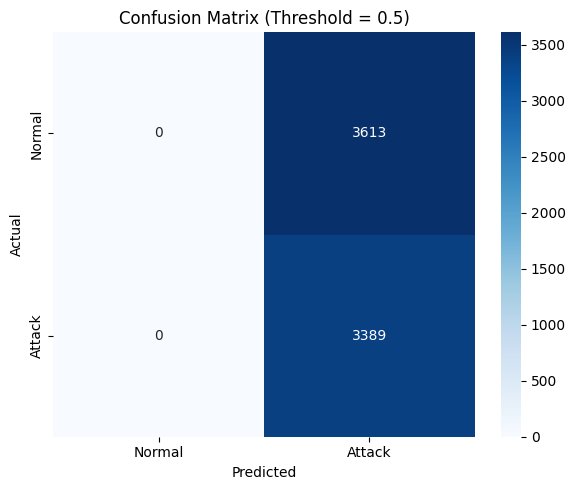

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_05 = confusion_matrix(y_true, y_pred_05)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_05,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


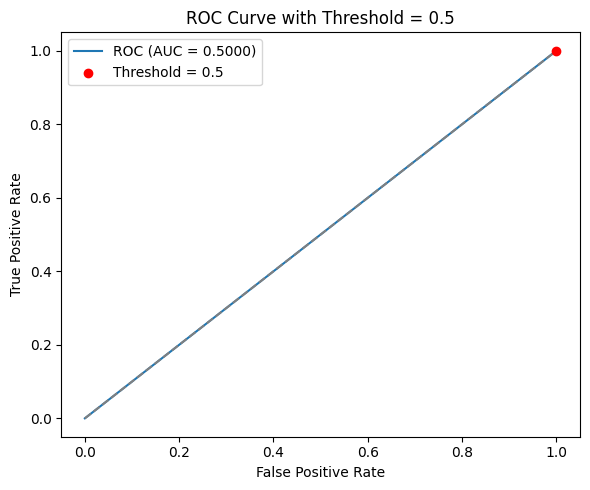

In [16]:
from sklearn.metrics import roc_curve, auc
import numpy as np

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# cari titik threshold terdekat ke 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.scatter(
    fpr[idx_05],
    tpr[idx_05],
    color="red",
    label="Threshold = 0.5",
    zorder=5
)
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold = 0.5")
plt.legend()
plt.tight_layout()
plt.show()


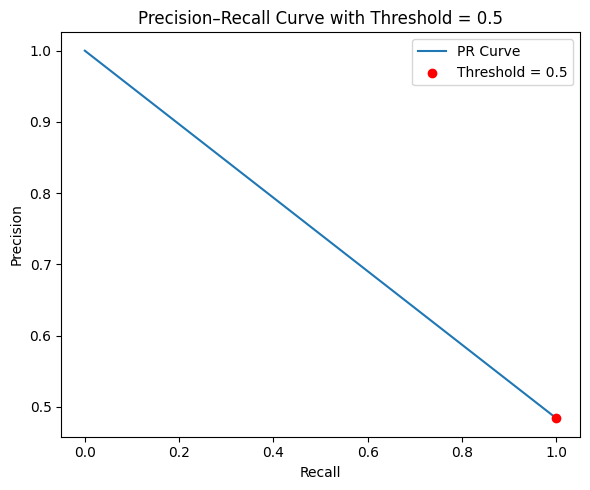

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)

# cari threshold terdekat 0.5 di PR curve
idx_05_pr = np.argmin(np.abs(pr_thresholds - 0.5))

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="PR Curve")
plt.scatter(
    recall[idx_05_pr],
    precision[idx_05_pr],
    color="red",
    label="Threshold = 0.5",
    zorder=5
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve with Threshold = 0.5")
plt.legend()
plt.tight_layout()
plt.show()


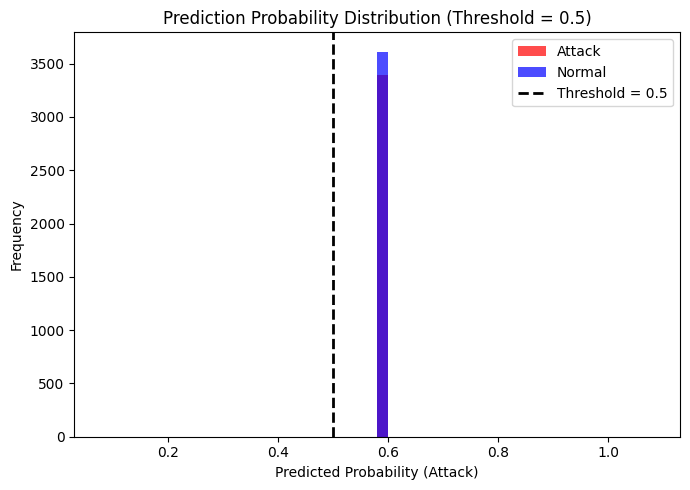

In [18]:
plt.figure(figsize=(7,5))
plt.hist(
    y_prob[y_true == 1],
    bins=50,
    alpha=0.7,
    label="Attack",
    color="red"
)
plt.hist(
    y_prob[y_true == 0],
    bins=50,
    alpha=0.7,
    label="Normal",
    color="blue"
)

plt.axvline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.5"
)

plt.xlabel("Predicted Probability (Attack)")
plt.ylabel("Frequency")
plt.title("Prediction Probability Distribution (Threshold = 0.5)")
plt.legend()
plt.tight_layout()
plt.show()


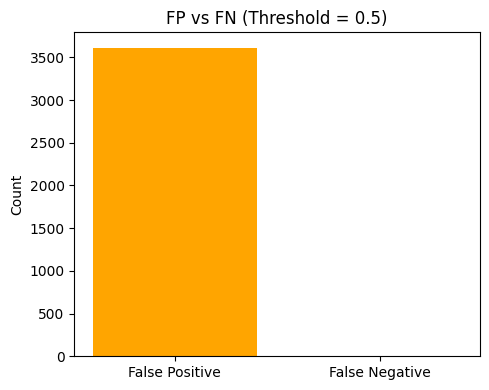

In [19]:
plt.figure(figsize=(5,4))
plt.bar(
    ["False Positive", "False Negative"],
    [fp, fn],
    color=["orange", "red"]
)
plt.title("FP vs FN (Threshold = 0.5)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [20]:
PRED_PATH = os.path.join(MODEL_DIR, "2cnn_tow_ids_predictions.npz")

np.savez(PRED_PATH, y_true=y_true, y_prob=y_prob)

print("Prediksi disimpan.")


Prediksi disimpan.


In [21]:
# # load PREDIKSI 

# data = np.load(PRED_PATH)
# y_true = data["y_true"]
# y_prob = data["y_prob"]


In [22]:
print("y_prob min:", y_prob.min())
print("y_prob max:", y_prob.max())
print("y_prob mean:", y_prob.mean())


y_prob min: 0.58001393
y_prob max: 0.58001393
y_prob mean: 0.5800139


In [23]:
print(np.bincount(y))


NameError: name 'y' is not defined